# Stance Results Team Analysis (Raw Runs Only)

This notebook computes all analyses directly from run-level files under:
`../data_out/semeval2016_task6_testdata_gold/*/document_assignments.csv`

No precomputed summary CSVs are used.


## Step 1 - What we want to understand

1. How does prompting technique affect performance?
2. Do smaller models gain more from richer prompts than larger models?
3. Which models agree most with each other?
4. Is scale-based prompting (`task_definition_scale`) better or worse than direct stance (`task_definition`)?

### Metrics
- Primary: macro F1
- Secondary: accuracy
- Agreement: raw agreement and Cohen's kappa


In [186]:
from pathlib import Path
import re
from itertools import combinations
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, cohen_kappa_score

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 200)

RUNS_ROOT = Path('../data_out/semeval2016_task6_testdata_gold')
LABELS = ['FAVOR', 'AGAINST', 'NONE']
FIXED_PROMPT = 'question'
BASELINE_PROMPT = 'default_no_label_definitions'
PROGRESSION_PROMPTS = ['default_no_label_definitions', 'default', 'task_definition', 'few_shot', 'cot', 'question']
SEPARATE_PROMPTS = ['task_definition_scale']
MODEL_PALETTE = 'tab20'  # Change this to e.g. 'Set2', 'Dark2', 'viridis'
RNG = np.random.default_rng(42)

assert RUNS_ROOT.exists(), f'Missing folder: {RUNS_ROOT.resolve()}'


In [187]:
def parse_run_folder(folder_name: str):
    # Expected pattern: ..._semeval2016_task6_testdata_gold_<model>_equal_<prompt>
    m = re.match(r'.*semeval2016_task6_testdata_gold_(.+)_equal_(.+)$', folder_name)
    if not m:
        return None
    model, prompt = m.group(1), m.group(2)
    return model, prompt


def norm_label(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper()
    # robust normalization for occasional noisy labels
    if 'FAVOR' in s:
        return 'FAVOR'
    if 'AGAINST' in s:
        return 'AGAINST'
    if s in {'NONE', 'NEITHER', 'NEUTRAL'}:
        return 'NONE'
    return s


def bootstrap_ci_mean(values, n_boot=5000, ci=95):
    arr = np.array(values, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return np.nan, np.nan, np.nan
    means = np.empty(n_boot)
    for i in range(n_boot):
        sample = RNG.choice(arr, size=len(arr), replace=True)
        means[i] = np.mean(sample)
    alpha = (100 - ci) / 2
    lo, hi = np.percentile(means, [alpha, 100 - alpha])
    return float(np.mean(arr)), float(lo), float(hi)


In [188]:
# Load all run-level files
run_files = sorted(RUNS_ROOT.glob('*/document_assignments.csv'))
if not run_files:
    raise FileNotFoundError(f'No run files found under {RUNS_ROOT}')

system_frames = {}
meta_rows = []

for fp in run_files:
    parsed = parse_run_folder(fp.parent.name)
    if parsed is None:
        continue
    model, prompt = parsed

    df = pd.read_csv(fp)
    needed = {'doc_id', 'original_stance', 'predicted_stance'}
    missing = needed - set(df.columns)
    if missing:
        continue

    df = df[['doc_id', 'original_stance', 'predicted_stance']].copy()
    df['doc_id'] = df['doc_id'].astype(str)
    df['gold'] = df['original_stance'].map(norm_label)
    df['pred'] = df['predicted_stance'].map(norm_label)

    df = df[df['gold'].isin(LABELS) & df['pred'].isin(LABELS)].copy()

    system = f'{model} | {prompt}'
    system_frames[system] = df
    meta_rows.append({'system': system, 'model': model, 'prompt': prompt, 'run_folder': fp.parent.name, 'n_eval': len(df)})

meta_df = pd.DataFrame(meta_rows).sort_values(['model', 'prompt'])
print('systems loaded:', len(system_frames))
print('models:', meta_df['model'].nunique())
print('prompts:', sorted(meta_df['prompt'].unique()))
meta_df.head()


systems loaded: 84
models: 12
prompts: ['cot', 'default', 'default_no_label_definitions', 'few_shot', 'question', 'task_definition', 'task_definition_scale']


,system,model,prompt,run_folder,n_eval
0,DeepSeek-R1-Distill-Llama-8B | cot,DeepSeek-R1-Distill-Llama-8B,cot,GenAIStanceOneShot_1249_semeval2016_task6_test...,1249
1,DeepSeek-R1-Distill-Llama-8B | default,DeepSeek-R1-Distill-Llama-8B,default,GenAIStanceOneShot_1249_semeval2016_task6_test...,1249
2,DeepSeek-R1-Distill-Llama-8B | default_no_labe...,DeepSeek-R1-Distill-Llama-8B,default_no_label_definitions,GenAIStanceOneShot_1249_semeval2016_task6_test...,1249
3,DeepSeek-R1-Distill-Llama-8B | few_shot,DeepSeek-R1-Distill-Llama-8B,few_shot,GenAIStanceOneShot_1249_semeval2016_task6_test...,1249
4,DeepSeek-R1-Distill-Llama-8B | question,DeepSeek-R1-Distill-Llama-8B,question,GenAIStanceOneShot_1249_semeval2016_task6_test...,1249


In [189]:
# Compute per-system performance metrics directly from predictions
metric_rows = []
for _, m in meta_df.iterrows():
    s = m['system']
    d = system_frames[s]
    y_true = d['gold'].values
    y_pred = d['pred'].values

    p, r, f, sup = precision_recall_fscore_support(y_true, y_pred, labels=LABELS, zero_division=0)

    metric_rows.append({
        'system': s,
        'model': m['model'],
        'prompt': m['prompt'],
        'n_eval': int(len(d)),
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, labels=LABELS, average='macro', zero_division=0),
        'micro_f1': f1_score(y_true, y_pred, labels=LABELS, average='micro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, labels=LABELS, average='weighted', zero_division=0),
        'macro_precision': float(np.mean(p)),
        'macro_recall': float(np.mean(r)),
        'f1_FAVOR': f[0], 'f1_AGAINST': f[1], 'f1_NONE': f[2],
        'support_FAVOR': sup[0], 'support_AGAINST': sup[1], 'support_NONE': sup[2],
    })

metrics = pd.DataFrame(metric_rows).sort_values('macro_f1', ascending=False)
metrics.head(12)


,system,model,prompt,n_eval,accuracy,macro_f1,micro_f1,weighted_f1,macro_precision,macro_recall,f1_FAVOR,f1_AGAINST,f1_NONE,support_FAVOR,support_AGAINST,support_NONE
69,gpt-5.2 | task_definition_scale,gpt-5.2,task_definition_scale,1248,0.774038,0.758067,0.774038,0.778029,0.746641,0.806551,0.772487,0.807103,0.694611,304,715,229
67,gpt-5.2 | question,gpt-5.2,question,1249,0.761409,0.748589,0.761409,0.767381,0.734479,0.805235,0.775862,0.792822,0.677083,304,715,230
68,gpt-5.2 | task_definition,gpt-5.2,task_definition,1249,0.757406,0.746262,0.757406,0.764679,0.736204,0.808953,0.776471,0.789082,0.673235,304,715,230
59,gpt-5-mini | few_shot,gpt-5-mini,few_shot,1246,0.755217,0.746007,0.755217,0.760308,0.734960,0.812215,0.788051,0.776569,0.673401,302,714,230
58,gpt-5-mini | default_no_label_definitions,gpt-5-mini,default_no_label_definitions,1246,0.753612,0.745272,0.753612,0.759809,0.737193,0.815015,0.783745,0.776748,0.675325,303,714,229
61,gpt-5-mini | task_definition,gpt-5-mini,task_definition,1242,0.752818,0.743816,0.752818,0.759461,0.736009,0.812140,0.779562,0.778716,0.673171,302,711,229
63,gpt-5.2 | cot,gpt-5.2,cot,1237,0.752627,0.741062,0.752627,0.759382,0.730276,0.800955,0.774381,0.783264,0.665541,304,705,228
66,gpt-5.2 | few_shot,gpt-5.2,few_shot,1237,0.751819,0.739770,0.751819,0.759222,0.729468,0.802402,0.779412,0.783333,0.656566,300,711,226
57,gpt-5-mini | default,gpt-5-mini,default,1245,0.745382,0.737384,0.745382,0.752409,0.732705,0.808001,0.771261,0.771064,0.669826,304,711,230
64,gpt-5.2 | default,gpt-5.2,default,1249,0.747798,0.736548,0.747798,0.756306,0.730335,0.801896,0.761481,0.783626,0.664537,304,715,230


## Q1 - Prompting effect on performance


In [190]:
base_prompt_order = [
    'default_no_label_definitions',
    'default',
    'task_definition',
    'few_shot',
    'cot',
    'question',
    'task_definition_scale',
]

available_prompts = set(metrics['prompt'].dropna().unique())
prompt_order = [p for p in base_prompt_order if p in available_prompts]
metrics['prompt'] = pd.Categorical(metrics['prompt'], categories=prompt_order, ordered=True)

prompt_effect = (
    metrics.groupby('prompt', dropna=False, observed=True)
    .agg(
        runs=('system', 'count'),
        macro_f1_mean=('macro_f1', 'mean'),
        macro_f1_std=('macro_f1', 'std'),
        accuracy_mean=('accuracy', 'mean'),
        accuracy_std=('accuracy', 'std'),
    )
    .reset_index()
)

progression_order = [p for p in PROGRESSION_PROMPTS if p in available_prompts]
progression_df = metrics[metrics['prompt'].isin(progression_order)].copy()
progression_df['prompt'] = pd.Categorical(progression_df['prompt'], categories=progression_order, ordered=True)

prompt_effect.sort_values('macro_f1_mean', ascending=False)


,prompt,runs,macro_f1_mean,macro_f1_std,accuracy_mean,accuracy_std
4,cot,12,0.620466,0.075735,0.633181,0.078322
5,question,12,0.617988,0.096970,0.633791,0.101138
0,default_no_label_definitions,12,0.598583,0.091479,0.605681,0.094207
3,few_shot,12,0.590583,0.129927,0.598588,0.125842
2,task_definition,12,0.589331,0.115301,0.595584,0.118019
1,default,12,0.583036,0.100275,0.583049,0.104992
6,task_definition_scale,12,0.518505,0.163188,0.530821,0.162891


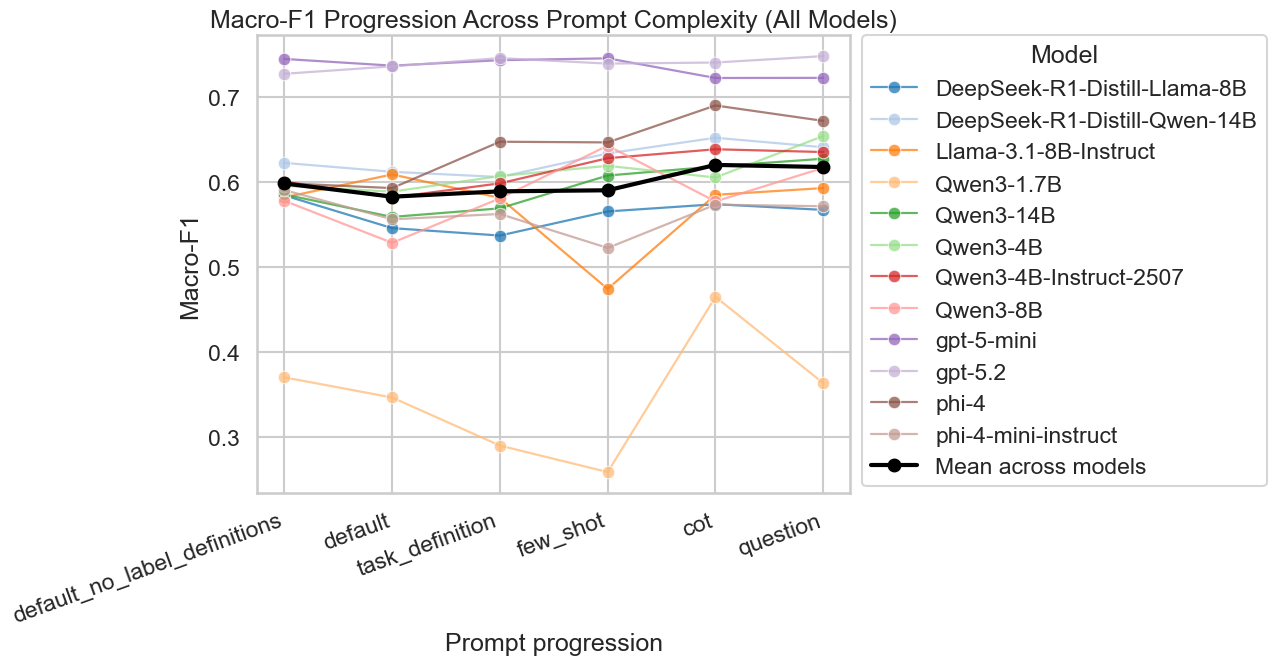

In [191]:
# Plot all model points across prompt progression + overall mean trend
plt.figure(figsize=(13, 7))

# Individual model trajectories (clean legend, no text clutter)
sns.lineplot(
    data=progression_df.sort_values(['model', 'prompt']),
    x='prompt',
    y='macro_f1',
    hue='model',
    marker='o',
    dashes=False,
    estimator=None,
    alpha=0.75,
    linewidth=1.6,
    palette=MODEL_PALETTE,
)

# Mean trajectory (highlighted)
mean_traj = (
    progression_df.groupby('prompt', observed=True)['macro_f1']
    .mean()
    .reindex(progression_order)
    .reset_index()
)
plt.plot(
    mean_traj['prompt'].astype(str),
    mean_traj['macro_f1'],
    marker='o',
    linewidth=3,
    color='black',
    label='Mean across models'
)

plt.title('Macro-F1 Progression Across Prompt Complexity (All Models)')
plt.xlabel('Prompt progression')
plt.ylabel('Macro-F1')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, frameon=True)
plt.tight_layout()
plt.show()


In [192]:
# Stepwise deltas between adjacent progression prompts (model-wise)
step_pairs = list(zip(progression_order[:-1], progression_order[1:]))
step_rows = []
for p1, p2 in step_pairs:
    left = progression_df[progression_df['prompt'] == p1][['model', 'macro_f1']].rename(columns={'macro_f1': 'm1'})
    right = progression_df[progression_df['prompt'] == p2][['model', 'macro_f1']].rename(columns={'macro_f1': 'm2'})
    j = left.merge(right, on='model', how='inner')
    if j.empty:
        continue
    delta = j['m2'] - j['m1']
    step_rows.append({
        'from_prompt': p1,
        'to_prompt': p2,
        'n_models': len(j),
        'mean_delta_macro_f1': delta.mean(),
        'median_delta_macro_f1': delta.median(),
        'wins': int((delta > 0).sum()),
        'losses': int((delta < 0).sum()),
    })

stepwise_progression = pd.DataFrame(step_rows)

# Keep baseline-gain table for Q2 computations
base = metrics[metrics['prompt'] == BASELINE_PROMPT][['model', 'macro_f1', 'accuracy']].rename(
    columns={'macro_f1': 'macro_f1_baseline', 'accuracy': 'accuracy_baseline'}
)
gains = metrics.merge(base, on='model', how='left')
gains['macro_f1_gain_vs_baseline'] = gains['macro_f1'] - gains['macro_f1_baseline']
gains['accuracy_gain_vs_baseline'] = gains['accuracy'] - gains['accuracy_baseline']

print(f'Progression order: {progression_order}')
stepwise_progression


Progression order: ['default_no_label_definitions', 'default', 'task_definition', 'few_shot', 'cot', 'question']


,from_prompt,to_prompt,n_models,mean_delta_macro_f1,median_delta_macro_f1,wins,losses
0,default_no_label_definitions,default,12,-0.015547,-0.014616,2,10
1,default,task_definition,12,0.006295,0.008074,8,4
2,task_definition,few_shot,12,0.001252,0.007113,7,5
3,few_shot,cot,12,0.029883,0.010613,9,3
4,cot,question,12,-0.002478,-0.000872,6,6


## Q2 - Correlation across all prompt-progression data points


In [193]:
# Build all progression points and compute correlation with prompt stage
prompt_stage_map = {p: i for i, p in enumerate(progression_order)}

corr_points = progression_df[['model', 'prompt', 'macro_f1']].copy()
corr_points['prompt_stage'] = corr_points['prompt'].astype(str).map(prompt_stage_map)

overall_stage_corr = corr_points['prompt_stage'].corr(corr_points['macro_f1'])

per_model_stage_corr = (
    corr_points.groupby('model')
    .apply(lambda d: d['prompt_stage'].corr(d['macro_f1']))
    .reset_index(name='corr_prompt_stage_vs_macro_f1')
    .sort_values('corr_prompt_stage_vs_macro_f1', ascending=False)
)

print(f'Overall correlation across all model-prompt points: {overall_stage_corr:.3f}')
per_model_stage_corr


Overall correlation across all model-prompt points: 0.103


/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_38137/728732004.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d['prompt_stage'].corr(d['macro_f1']))


,model,corr_prompt_stage_vs_macro_f1
10,phi-4,0.904270
6,Qwen3-4B-Instruct-2507,0.857752
4,Qwen3-14B,0.825813
5,Qwen3-4B,0.815301
9,gpt-5.2,0.800112
1,DeepSeek-R1-Distill-Qwen-14B,0.728139
7,Qwen3-8B,0.549457
3,Qwen3-1.7B,0.215874
0,DeepSeek-R1-Distill-Llama-8B,0.082478
2,Llama-3.1-8B-Instruct,-0.136714


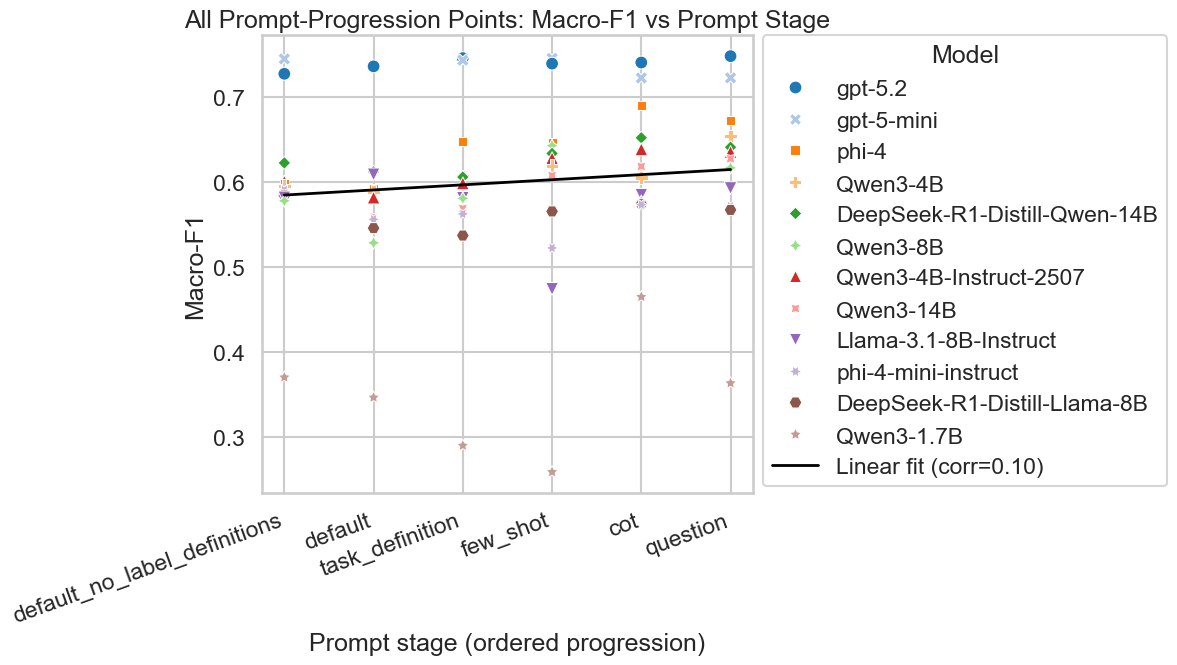

In [194]:
# Scatter all points with model-identifying legend
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=corr_points,
    x='prompt_stage',
    y='macro_f1',
    hue='model',
    style='model',
    s=85,
    palette=MODEL_PALETTE,
)

# Fit linear trend over all points
x = corr_points['prompt_stage'].values
y = corr_points['macro_f1'].values
coef = np.polyfit(x, y, 1)
xline = np.linspace(x.min(), x.max(), 100)
yline = coef[0] * xline + coef[1]
plt.plot(xline, yline, color='black', linewidth=2, label=f'Linear fit (corr={overall_stage_corr:.2f})')

plt.xticks(list(prompt_stage_map.values()), list(prompt_stage_map.keys()), rotation=20, ha='right')
plt.title('All Prompt-Progression Points: Macro-F1 vs Prompt Stage')
plt.xlabel('Prompt stage (ordered progression)')
plt.ylabel('Macro-F1')
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, frameon=True)
plt.tight_layout()
plt.show()


## Q3 - Model agreement (fixed prompt only)

We keep prompt fixed (`question`) so agreement reflects model similarity, not prompt differences.


In [195]:
# Build predictions by model at fixed prompt
fixed = metrics[metrics['prompt'] == FIXED_PROMPT].copy()
fixed_systems = fixed[['model', 'system']]

pred_by_model = {}
for _, r in fixed_systems.iterrows():
    d = system_frames[r['system']][['doc_id', 'pred']].drop_duplicates('doc_id').set_index('doc_id')
    pred_by_model[r['model']] = d['pred']

pair_rows = []
models = sorted(pred_by_model.keys())
for m1, m2 in combinations(models, 2):
    join = pd.concat([pred_by_model[m1], pred_by_model[m2]], axis=1, keys=['p1', 'p2']).dropna()
    if len(join) == 0:
        continue
    raw_agreement = (join['p1'] == join['p2']).mean()
    kappa = cohen_kappa_score(join['p1'], join['p2'], labels=LABELS)
    pair_rows.append({'model_1': m1, 'model_2': m2, 'n_common': len(join), 'raw_agreement': raw_agreement, 'cohens_kappa': kappa})

pair_df = pd.DataFrame(pair_rows)
print('pairs compared:', len(pair_df))

print('Top by raw agreement')
display(pair_df.sort_values('raw_agreement', ascending=False).head(12))
print('Top by kappa')
display(pair_df.sort_values('cohens_kappa', ascending=False).head(12))

# Build square matrices for heatmaps
models_sorted = sorted(models)
raw_matrix = pd.DataFrame(index=models_sorted, columns=models_sorted, dtype=float)
kappa_matrix = pd.DataFrame(index=models_sorted, columns=models_sorted, dtype=float)

for m in models_sorted:
    raw_matrix.loc[m, m] = 1.0
    kappa_matrix.loc[m, m] = 1.0

for _, r in pair_df.iterrows():
    m1, m2 = r['model_1'], r['model_2']
    raw_matrix.loc[m1, m2] = r['raw_agreement']
    raw_matrix.loc[m2, m1] = r['raw_agreement']
    kappa_matrix.loc[m1, m2] = r['cohens_kappa']
    kappa_matrix.loc[m2, m1] = r['cohens_kappa']


pairs compared: 66
Top by raw agreement


,model_1,model_2,n_common,raw_agreement,cohens_kappa
60,gpt-5-mini,gpt-5.2,1248,0.882212,0.821390
63,gpt-5.2,phi-4,1249,0.790232,0.680382
61,gpt-5-mini,phi-4,1248,0.785256,0.673526
17,DeepSeek-R1-Distill-Qwen-14B,gpt-5-mini,1248,0.782853,0.674567
13,DeepSeek-R1-Distill-Qwen-14B,Qwen3-14B,1249,0.778223,0.662110
40,Qwen3-14B,Qwen3-8B,1246,0.776886,0.660992
41,Qwen3-14B,gpt-5-mini,1248,0.769231,0.656257
19,DeepSeek-R1-Distill-Qwen-14B,phi-4,1249,0.767014,0.650002
47,Qwen3-4B,gpt-5-mini,1244,0.763666,0.644358
16,DeepSeek-R1-Distill-Qwen-14B,Qwen3-8B,1246,0.759230,0.635301


Top by kappa


,model_1,model_2,n_common,raw_agreement,cohens_kappa
60,gpt-5-mini,gpt-5.2,1248,0.882212,0.821390
63,gpt-5.2,phi-4,1249,0.790232,0.680382
17,DeepSeek-R1-Distill-Qwen-14B,gpt-5-mini,1248,0.782853,0.674567
61,gpt-5-mini,phi-4,1248,0.785256,0.673526
13,DeepSeek-R1-Distill-Qwen-14B,Qwen3-14B,1249,0.778223,0.662110
40,Qwen3-14B,Qwen3-8B,1246,0.776886,0.660992
41,Qwen3-14B,gpt-5-mini,1248,0.769231,0.656257
19,DeepSeek-R1-Distill-Qwen-14B,phi-4,1249,0.767014,0.650002
47,Qwen3-4B,gpt-5-mini,1244,0.763666,0.644358
42,Qwen3-14B,gpt-5.2,1249,0.759007,0.642889


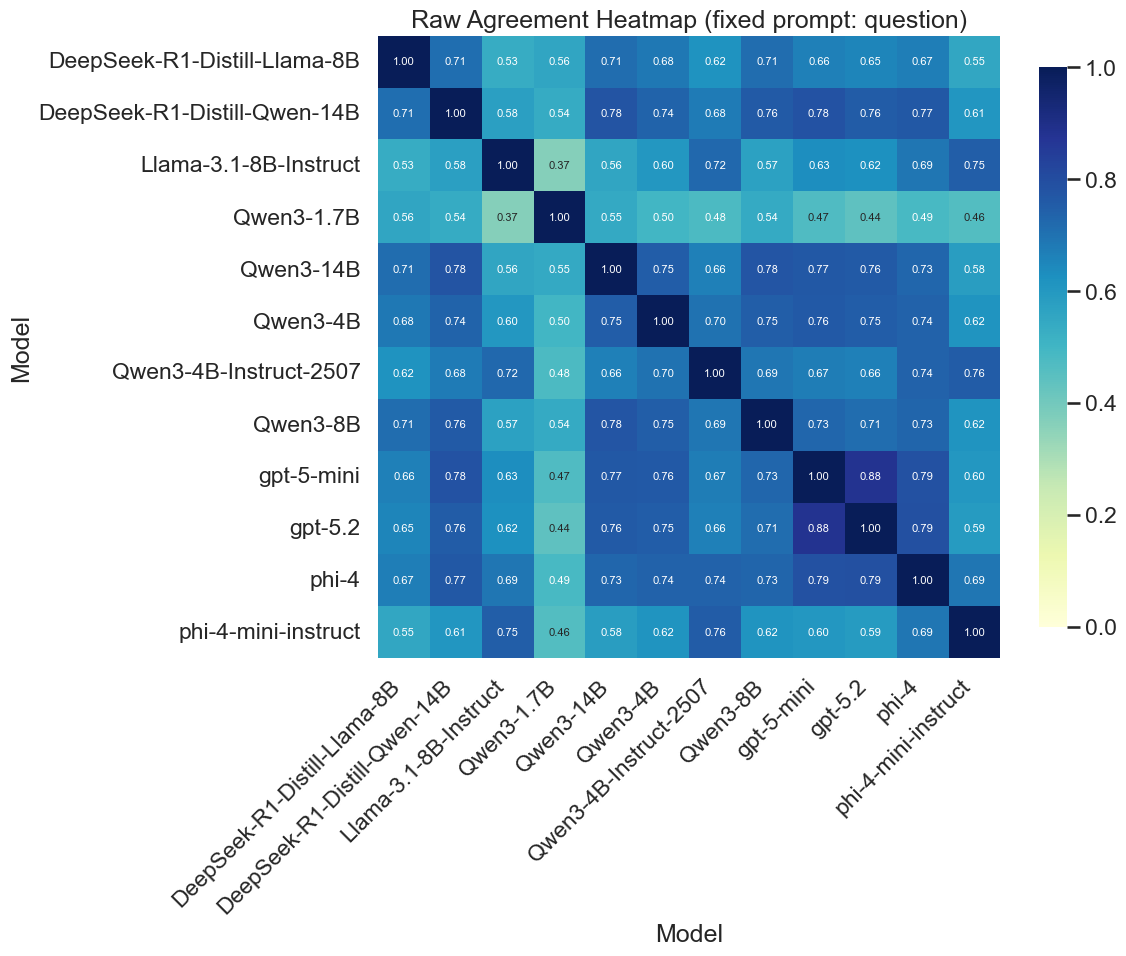

In [196]:
# Raw agreement heatmap (separate figure for readability)
plt.figure(figsize=(12, 10))
sns.heatmap(
    raw_matrix,
    cmap='YlGnBu',
    vmin=0,
    vmax=1,
    square=True,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
    cbar_kws={'shrink': 0.85},
)
plt.title(f'Raw Agreement Heatmap (fixed prompt: {FIXED_PROMPT})')
plt.xlabel('Model')
plt.ylabel('Model')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


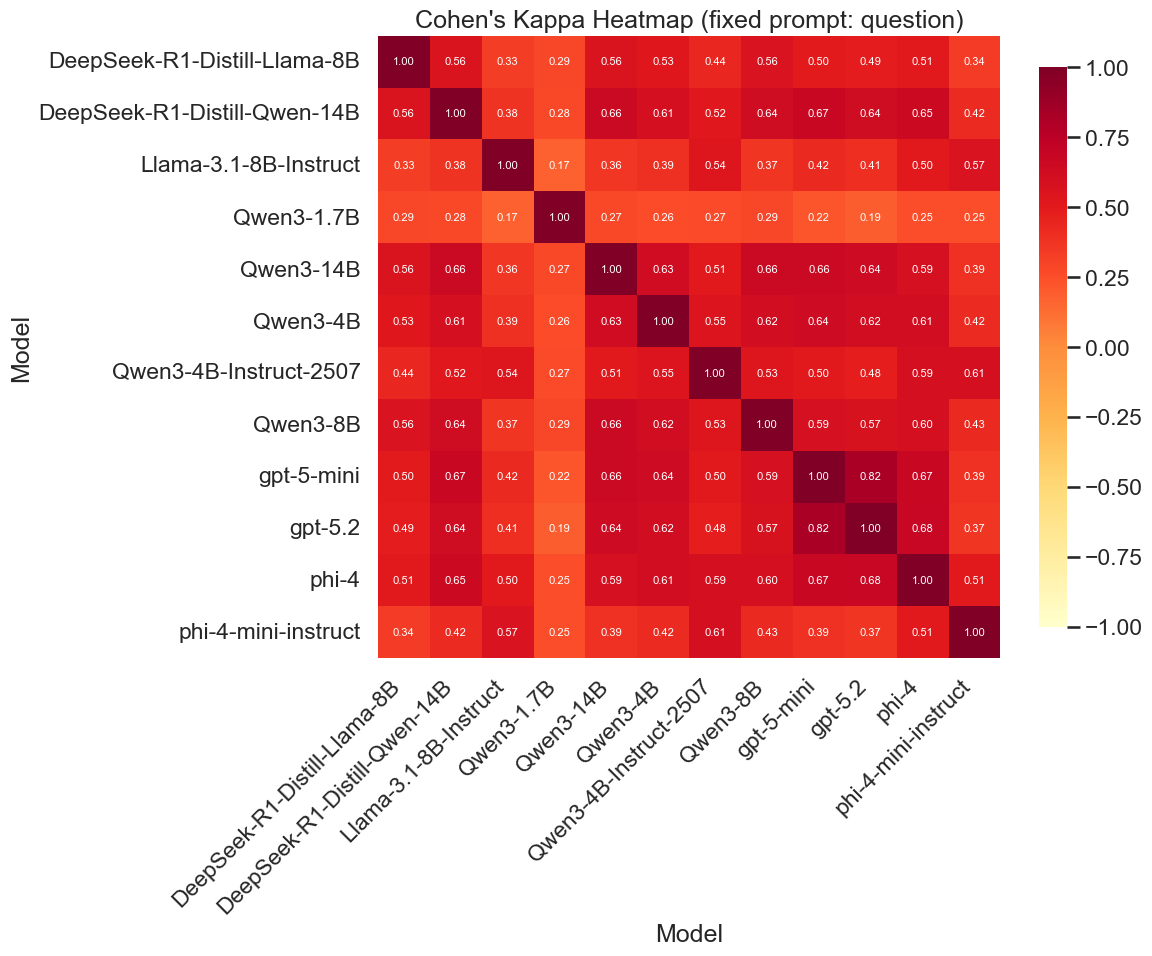

In [197]:
# Cohen's kappa heatmap (separate figure for readability)
plt.figure(figsize=(12, 10))
sns.heatmap(
    kappa_matrix,
    cmap='YlOrRd',
    vmin=-1,
    vmax=1,
    square=True,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
    cbar_kws={'shrink': 0.85},
)
plt.title(f"Cohen's Kappa Heatmap (fixed prompt: {FIXED_PROMPT})")
plt.xlabel('Model')
plt.ylabel('Model')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Q4 - Scale prompt vs direct stance


In [198]:
# Compare task_definition_scale vs task_definition within each model
pivot = metrics[metrics['prompt'].isin(['task_definition', 'task_definition_scale'])].pivot_table(
    index='model',
    columns='prompt',
    values=['macro_f1', 'accuracy'],
    aggfunc='mean'
)

exp2 = pd.DataFrame({
    'model': pivot.index,
    'task_definition_macro_f1': pivot[('macro_f1', 'task_definition')],
    'task_definition_scale_macro_f1': pivot[('macro_f1', 'task_definition_scale')],
    'task_definition_accuracy': pivot[('accuracy', 'task_definition')],
    'task_definition_scale_accuracy': pivot[('accuracy', 'task_definition_scale')],
}).reset_index(drop=True)

exp2['delta_macro_f1'] = exp2['task_definition_scale_macro_f1'] - exp2['task_definition_macro_f1']
exp2['delta_accuracy'] = exp2['task_definition_scale_accuracy'] - exp2['task_definition_accuracy']

exp2 = exp2.sort_values('delta_macro_f1', ascending=False)
exp2


/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_38137/3059287221.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = metrics[metrics['prompt'].isin(['task_definition', 'task_definition_scale'])].pivot_table(


,model,task_definition_macro_f1,task_definition_scale_macro_f1,task_definition_accuracy,task_definition_scale_accuracy,delta_macro_f1,delta_accuracy
10,phi-4,0.647767,0.708840,0.647718,0.723779,0.061072,0.076061
0,DeepSeek-R1-Distill-Llama-8B,0.537260,0.583566,0.529695,0.584468,0.046306,0.054773
9,gpt-5.2,0.746262,0.758067,0.757406,0.774038,0.011804,0.016633
1,DeepSeek-R1-Distill-Qwen-14B,0.606183,0.617631,0.597278,0.624199,0.011448,0.026921
11,phi-4-mini-instruct,0.562678,0.531922,0.572458,0.586869,-0.030757,0.014412
8,gpt-5-mini,0.743816,0.704743,0.752818,0.714744,-0.039073,-0.038074
3,Qwen3-1.7B,0.289862,0.239319,0.293835,0.267414,-0.050543,-0.026421
6,Qwen3-4B-Instruct-2507,0.598754,0.526695,0.610088,0.521217,-0.072059,-0.088871
4,Qwen3-14B,0.569295,0.439776,0.563651,0.428571,-0.129519,-0.135079
7,Qwen3-8B,0.581088,0.385706,0.574178,0.385621,-0.195382,-0.188557


In [199]:
summary_exp2 = pd.DataFrame({
    'models_compared': [len(exp2)],
    'mean_delta_macro_f1': [exp2['delta_macro_f1'].mean()],
    'median_delta_macro_f1': [exp2['delta_macro_f1'].median()],
    'wins_scale_macro_f1': [(exp2['delta_macro_f1'] > 0).sum()],
    'losses_scale_macro_f1': [(exp2['delta_macro_f1'] < 0).sum()],
    'mean_delta_accuracy': [exp2['delta_accuracy'].mean()],
    'wins_scale_accuracy': [(exp2['delta_accuracy'] > 0).sum()],
    'losses_scale_accuracy': [(exp2['delta_accuracy'] < 0).sum()],
})

m_mean, m_lo, m_hi = bootstrap_ci_mean(exp2['delta_macro_f1'])
a_mean, a_lo, a_hi = bootstrap_ci_mean(exp2['delta_accuracy'])

bootstrap_exp2 = pd.DataFrame({
    'metric': ['delta_macro_f1', 'delta_accuracy'],
    'mean': [m_mean, a_mean],
    'ci95_low': [m_lo, a_lo],
    'ci95_high': [m_hi, a_hi],
})

display(summary_exp2)
display(bootstrap_exp2)


,models_compared,mean_delta_macro_f1,median_delta_macro_f1,wins_scale_macro_f1,losses_scale_macro_f1,mean_delta_accuracy,wins_scale_accuracy,losses_scale_accuracy
0,12,-0.070826,-0.044808,4,8,-0.064763,5,7


,metric,mean,ci95_low,ci95_high
0,delta_macro_f1,-0.070826,-0.129809,-0.016506
1,delta_accuracy,-0.064763,-0.127855,-0.003824


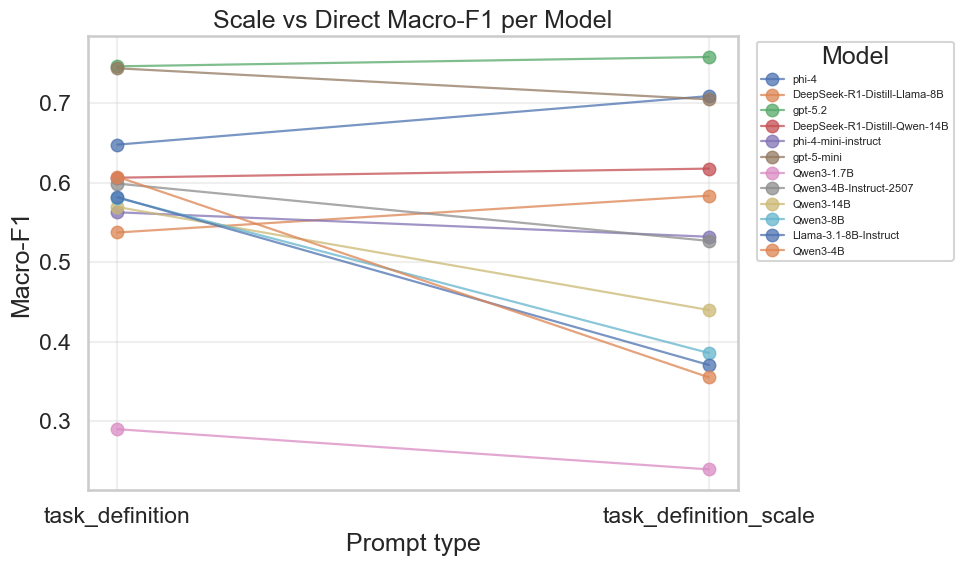

In [200]:
# Visual compare per model: paired values (direct vs scale)
plot_df = exp2.copy().sort_values('delta_macro_f1', ascending=False)

plt.figure(figsize=(10, 6))
for _, row in plot_df.iterrows():
    plt.plot(
        ['task_definition', 'task_definition_scale'],
        [row['task_definition_macro_f1'], row['task_definition_scale_macro_f1']],
        marker='o',
        alpha=0.75,
        linewidth=1.6,
        label=row['model']
    )

plt.title('Scale vs Direct Macro-F1 per Model')
plt.xlabel('Prompt type')
plt.ylabel('Macro-F1')
plt.grid(alpha=0.3)
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, frameon=True)
plt.tight_layout()
plt.show()


## Executive Summary (auto-generated)


In [201]:
best_prompt = prompt_effect.sort_values('macro_f1_mean', ascending=False).iloc[0]

top_ag = pair_df.sort_values('raw_agreement', ascending=False).iloc[0]
top_kp = pair_df.sort_values('cohens_kappa', ascending=False).iloc[0]

best_scale = exp2.sort_values('delta_macro_f1', ascending=False).iloc[0]
worst_scale = exp2.sort_values('delta_macro_f1', ascending=True).iloc[0]

m_mean, m_lo, m_hi = bootstrap_ci_mean(exp2['delta_macro_f1'])

if not stepwise_progression.empty:
    best_step = stepwise_progression.sort_values('mean_delta_macro_f1', ascending=False).iloc[0]
    step_line = f"- Prompt progression: biggest average jump is **{best_step['from_prompt']} -> {best_step['to_prompt']}** (mean delta **{best_step['mean_delta_macro_f1']:.3f}**)."
else:
    step_line = "- Prompt progression: insufficient data for adjacent-step comparison."

summary_lines = [
    f"- Baseline prompt (for gain calculations): **{BASELINE_PROMPT}**.",
    f"- Prompting: best average prompt overall is **{best_prompt['prompt']}** (macro-F1 mean **{best_prompt['macro_f1_mean']:.3f}**).",
    step_line,
    f"- All-point correlation (prompt stage vs macro-F1): **{overall_stage_corr:.2f}**.",
    f"- Fixed-prompt agreement ({FIXED_PROMPT}): top raw pair is **{top_ag['model_1']}** vs **{top_ag['model_2']}** (**{top_ag['raw_agreement']:.3f}**).",
    f"- Fixed-prompt agreement ({FIXED_PROMPT}): top kappa pair is **{top_kp['model_1']}** vs **{top_kp['model_2']}** (**{top_kp['cohens_kappa']:.3f}**).",
    f"- Scale vs direct: mean macro-F1 delta is **{m_mean:.3f}** with 95% CI **[{m_lo:.3f}, {m_hi:.3f}]**.",
    f"- Biggest scale winner: **{best_scale['model']}** (delta **{best_scale['delta_macro_f1']:.3f}**).",
    f"- Biggest scale loser: **{worst_scale['model']}** (delta **{worst_scale['delta_macro_f1']:.3f}**).",
]

print('\n'.join(summary_lines))


- Baseline prompt (for gain calculations): **default_no_label_definitions**.
- Prompting: best average prompt overall is **cot** (macro-F1 mean **0.620**).
- Prompt progression: biggest average jump is **few_shot -> cot** (mean delta **0.030**).
- All-point correlation (prompt stage vs macro-F1): **0.10**.
- Fixed-prompt agreement (question): top raw pair is **gpt-5-mini** vs **gpt-5.2** (**0.882**).
- Fixed-prompt agreement (question): top kappa pair is **gpt-5-mini** vs **gpt-5.2** (**0.821**).
- Scale vs direct: mean macro-F1 delta is **-0.071** with 95% CI **[-0.131, -0.016]**.
- Biggest scale winner: **phi-4** (delta **0.061**).
- Biggest scale loser: **Qwen3-4B** (delta **-0.252**).
